In [1]:
import numpy as np
import json
import torch
from pathlib import Path

from src.models.TransformerBottleneck_model import TransformerBottleneck_model
from src.models.model_utilizer import load_net
from src.dataloaders.ZerosPolesDataset import ConversionTransforms

In [2]:
if torch.cuda.is_available():
    print("CUDA is available!")
    print(f"Number of GPUs: {torch.cuda.device_count()}")
    print(f"Current GPU Name: {torch.cuda.get_device_name(0)}")
    print(f"CUDA Version used by PyTorch: {torch.version.cuda}")
else:
    print("CUDA is not available. PyTorch is using CPU.")

CUDA is not available. PyTorch is using CPU.


Настройки общие.

In [3]:
threshold = 0.5

Пути к каталогам.

In [4]:
model_name = 'TransformerBottleneck-model' #_halfwindow_8

config_dir = Path("./src/config/")

config_path = config_dir / "config.json"
assert config_path.exists(), f"Config not found: {config_path}"
with open(config_path, "r") as f:
    general_config = json.load(f)

checkpoints_dir = Path(general_config['checkpoints_dir'])
logs_dir = Path(general_config['logs_dir'])

model_log_path = logs_dir / f"{model_name}.json"
assert model_log_path.exists(), f"Config not found: {model_log_path}"
with open(model_log_path, "r") as f:
    model_log = json.load(f)

train_log = model_log["train_log"]
best_epoch = model_log["summary"]["best_epoch"]


Импорт модели.

In [5]:
device = torch.device(general_config["device"].lower() if torch.cuda.is_available() else 'cpu')

model = TransformerBottleneck_model(
    in_channels = 4,
    out_channels = 4,
    features = model_log["metadata"]["model"]["feature_list"]
    )

model = model.to(device)
model, _, _, _ = load_net(
            net = model,
            checkpoints_file = checkpoints_dir / f"best_{model_name}.pth",
            device = device
            )

model.eval()


transform = ConversionTransforms(
        num_iter=2,
        return_input=False
        )

Restoring checkpoint:  checkpoints\best_TransformerBottleneck-model.pth


Перечень файлов.

In [6]:
sample_file_name_list = None#["LPF.csv"]

sample_dir = Path("test_samples")

if sample_file_name_list is None:
    sample_file_name_list = [f.name for f in sample_dir.iterdir() if f.is_file()]

Чтение данных и инференс.

In [7]:
data_list = []
for sample_file_name in sample_file_name_list:
        data_list.append(np.loadtxt(sample_dir / sample_file_name, delimiter=',', skiprows=1).T)

predictions_list = []
for data in data_list:
        inputs = torch.from_numpy(np.ascontiguousarray(transform(data), dtype=np.float32))
        with torch.no_grad():
                logits = model(inputs.unsqueeze(0).to(device))
                predictions_list.append((torch.sigmoid(logits.squeeze(0)) > threshold).float().detach().cpu().numpy())

Визуализация.

In [8]:
PLOT_CONFIG = {
    'fontsize': 14,
    'fontsize_legend': 10,
    'fig_width': 8,
    'fig_height': 6,
    'markersize_data': 3,
    'markersize_mask': 10,
    'grid_alpha': 0.5,
    'plots': [
        {
            'ylabel': 'Magnitude, dB',
            'xlabel': 'Frequency, Hz', # 'Frequency, Hz', 'Samples',
            'xscale': 'log', # 'log', 'linear',
            'arg_key': 'freq', # 'freq', 'samples',
            'data_key': 'mag'
        },
        {
            'ylabel': 'Phase, deg',
            'xlabel': 'Frequency, Hz',
            'xscale': 'log',
            'arg_key': 'freq',
            'data_key': 'ph'
        }
    ],
    'masks': [
        {'label': 'left_pole',  'color': '#e377c2', 'marker': 'o'},
        {'label': 'right_pole', 'color': '#d62728', 'marker': 'p'},
        {'label': 'left_zero',  'color': '#bcbd22', 'marker': 's'},
        {'label': 'right_zero', 'color': '#ff7f0e', 'marker': '^'},
    ]
}

In [9]:
from typing import Union, Any, Dict, Optional, List
from matplotlib import pyplot as plt

def plot_responses(
    plot_config: Dict[str, Any],
    data: np.ndarray,
    title: str = None,
    regions: Optional[np.ndarray] = None,
    masks: Optional[List[int]] = None,
    save_path: Optional[Union[str, Path]] = None
    ) -> None:

    x_samples = np.arange(data.shape[-1])

    data_map = {
        'samples': x_samples,
        'freq': data[0,:],
        'mag' : data[1,:],
        'ph'  : data[2,:] * 180/np.pi
    }

    fig, axs = plt.subplots(
        nrows=2,
        ncols=1,
        figsize=(plot_config['fig_width'],
                 plot_config['fig_height'])
        )
    axs = np.array(axs).flatten()
    for idx, cfg in enumerate(plot_config['plots']):
        ax = axs[idx]
        
        # Plot Main Data.
        x_data = data_map[cfg['arg_key']]
        y_data = data_map[cfg['data_key']]
        
        ax.plot(x_data, y_data, '.', markersize=plot_config['markersize_data'], 
                linestyle='-', alpha=0.7)
        
        has_mask = False
        
        # Highlight regions.
        if regions is not None:
            for m_idx, m_cfg in enumerate(plot_config['masks']):
                indices = np.where(regions[m_idx] == 1)[0]
                if len(indices) > 0:
                    has_mask = True
                    ymin, ymax = ax.get_ylim()
                    ax.fill_between(x_data, ymin, ymax, where=regions[m_idx].astype(bool), 
                            color=m_cfg['color'], alpha=0.25, label=m_cfg['label'])

        # Mark masks.
        if masks is not None:
            for m_idx, m_cfg in enumerate(plot_config['masks']):
                indices = np.where(masks[m_idx] == 1)[0]
                if len(indices) > 0:
                    has_mask = True
                    ax.plot(x_data[indices], y_data[indices], 
                            marker=m_cfg['marker'], markersize=plot_config['markersize_mask'], 
                            linestyle='', color=m_cfg['color'], 
                            label=m_cfg['label'])
        
        # Set title (on the first plot of the sample group only).
        if title is not None:
            if idx == 0:
                ax.set_title(title, fontsize=plot_config['fontsize'], fontweight='bold')
            
        ax.set_xscale(cfg['xscale'])
        ax.set_ylabel(cfg['ylabel'], fontsize=plot_config['fontsize'])
        ax.set_xlabel(cfg['xlabel'], fontsize=plot_config['fontsize'])
        ax.grid(True, alpha=plot_config['grid_alpha'], axis='both', linestyle='--')
        
        # Only show legend if masks exist.
        if has_mask:
            ax.legend(fontsize=plot_config['fontsize_legend'], loc='best', framealpha=0.8)

    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, bbox_inches='tight')
    
    plt.show()
    plt.close(fig)

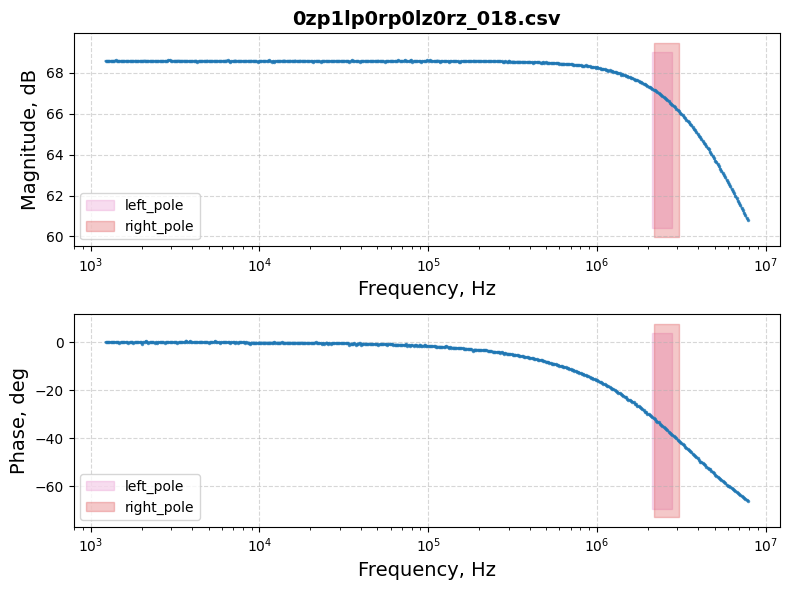

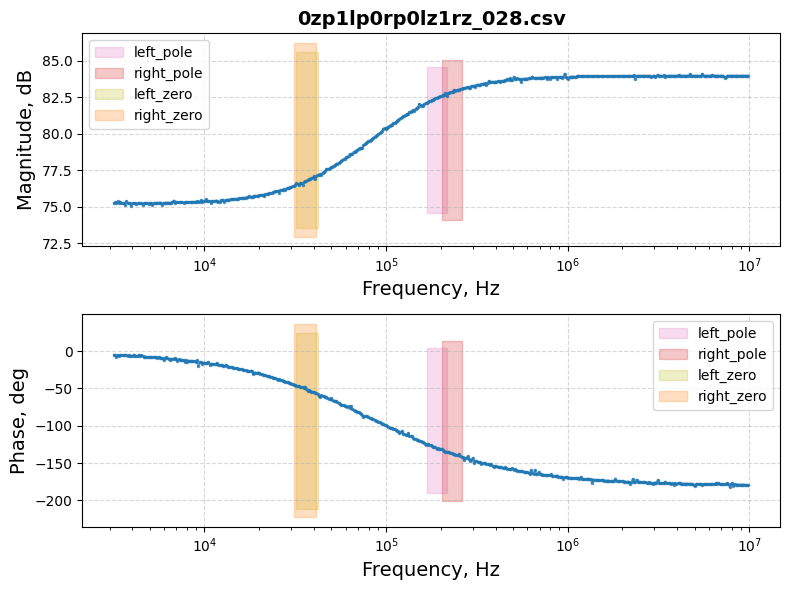

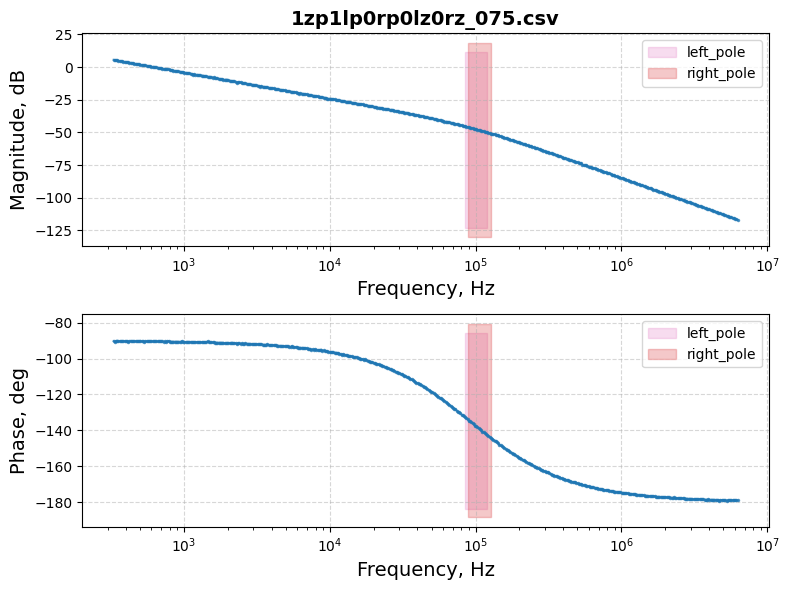

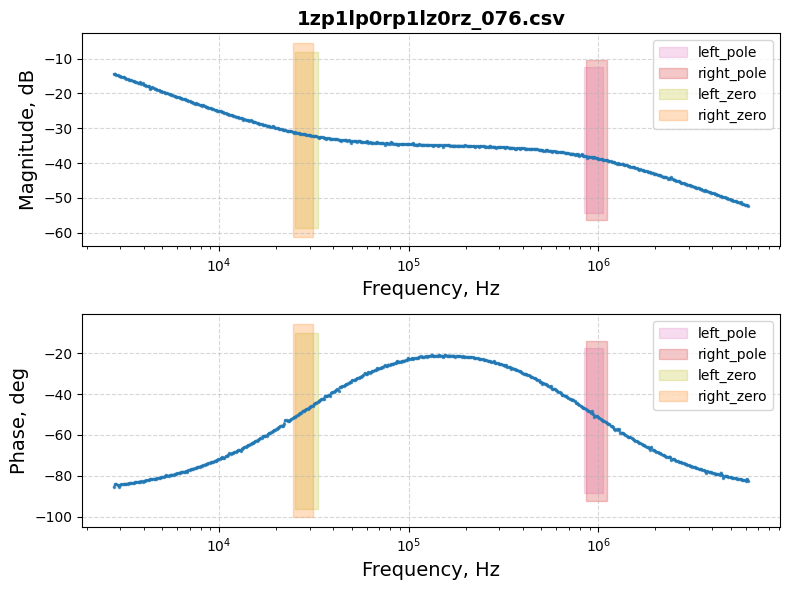

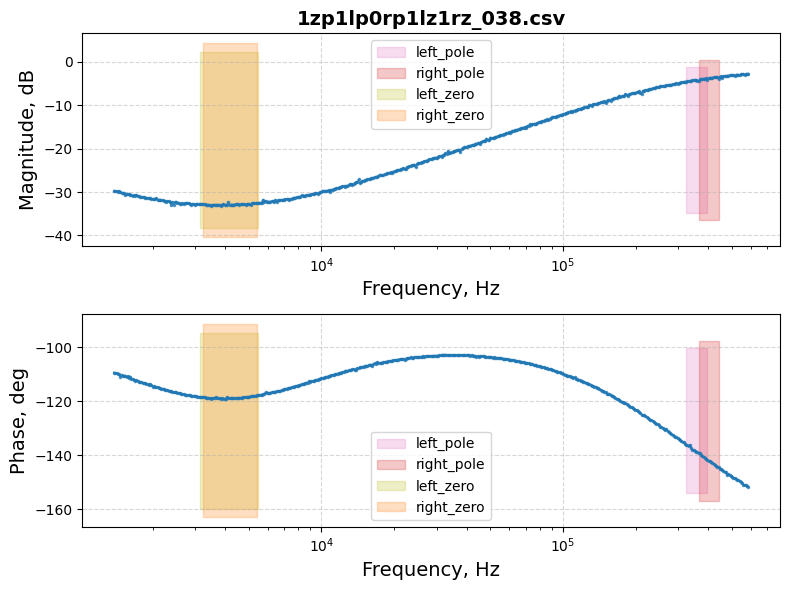

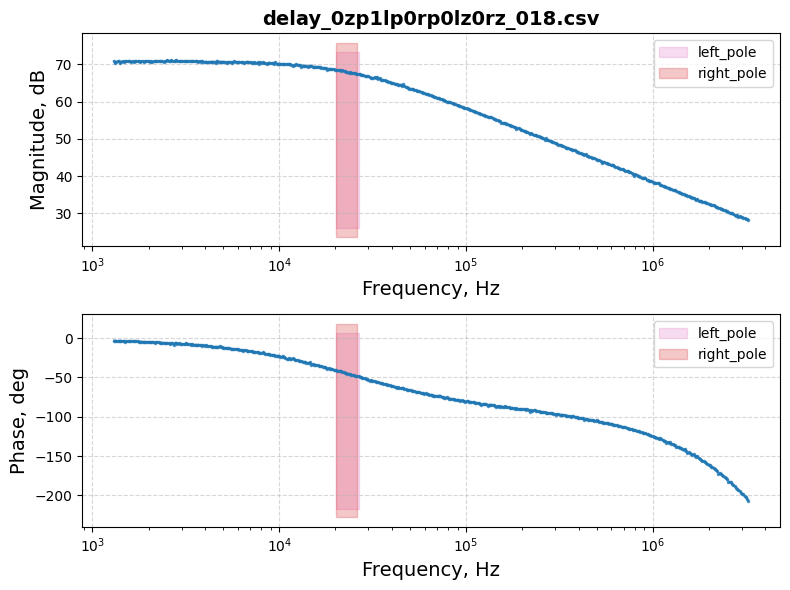

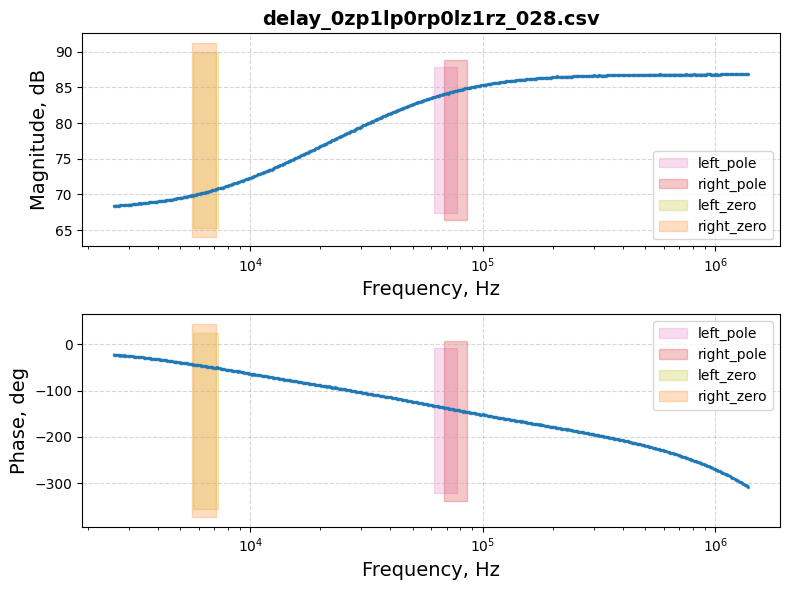

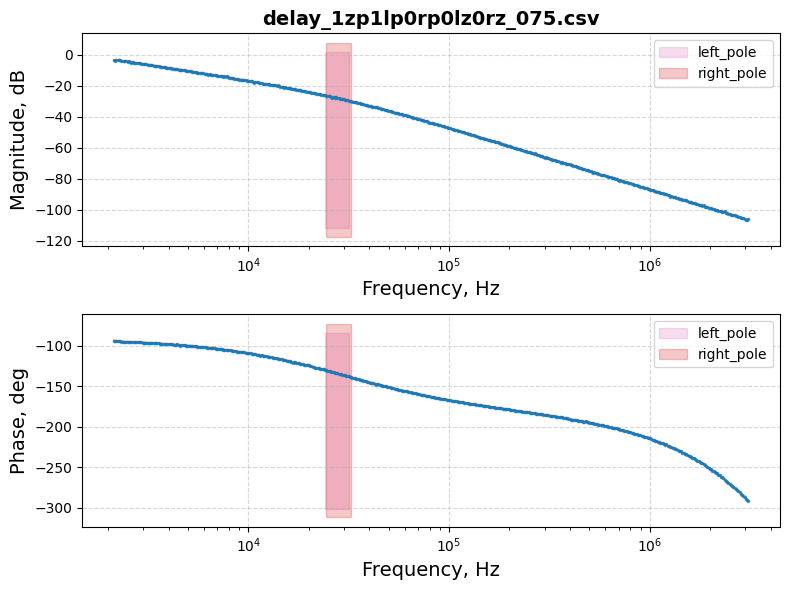

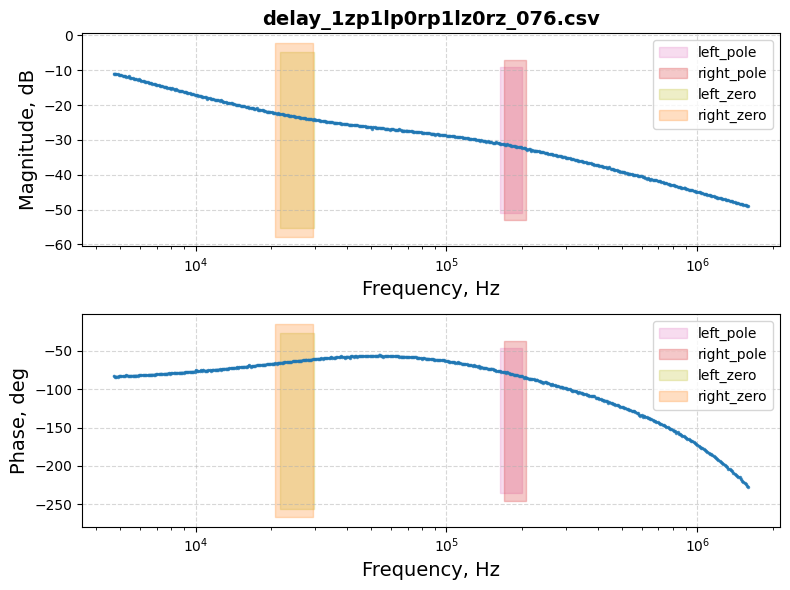

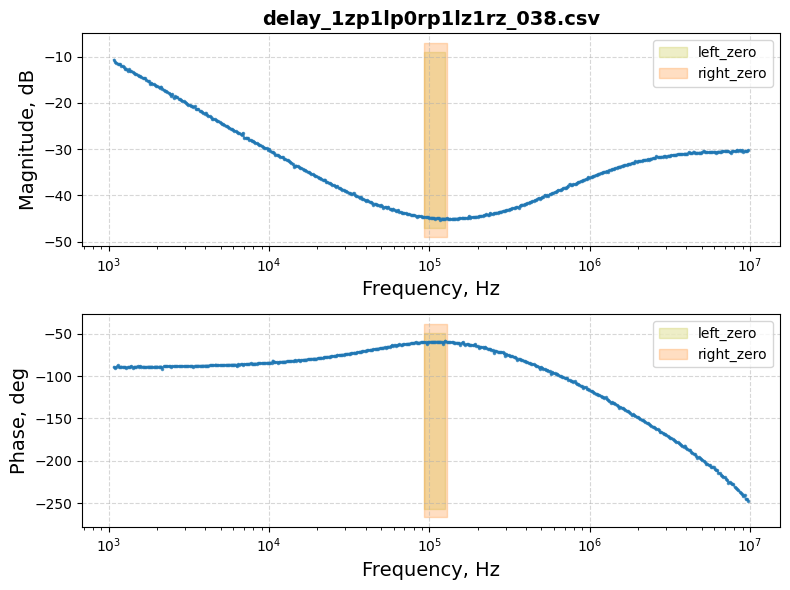

In [10]:
for data, predictions, sample_file_name in zip(data_list, predictions_list, sample_file_name_list):
    plot_responses(
        plot_config=PLOT_CONFIG,
        data=data,
        title=sample_file_name,
        regions=predictions
        )

# Дополнительный тест

Чтение данных и инференс.

In [11]:
sample_file_name_list = ["LPF.csv"]

sample_dir = Path("test_samples/extra")

if sample_file_name_list is None:
    sample_file_name_list = [f.name for f in sample_dir.iterdir() if f.is_file()]
    
data_list = []

for sample_file_name in sample_file_name_list:
        data_list.append(np.loadtxt(sample_dir / sample_file_name, delimiter=',', skiprows=1).T)

fp: 2134.0888
fz: 39788.7358


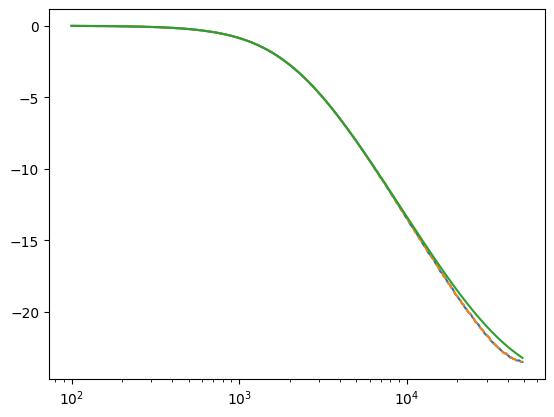

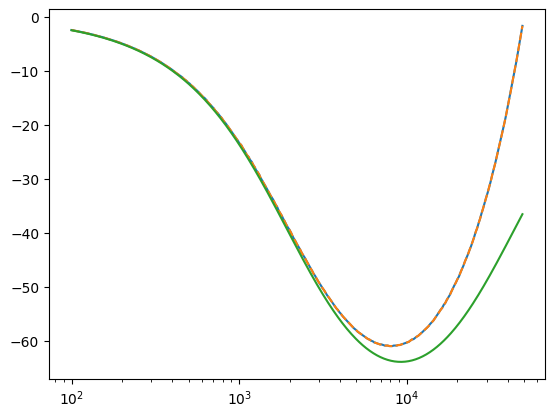

In [12]:
freq = data_list[0][0]
y_stack = np.array([data_list[0][1], data_list[0][2]])

freq_log = np.logspace(np.log10(freq.min()), np.log10(freq.max()), num=512)
y_new = np.array([np.interp(freq_log, freq, y) for y in y_stack])

fs = 100000
k = 12566.3706143592 / fs
fp = 2*k*fs /(2-k) / (2*np.pi)
fz = fs / np.pi
print('fp:', np.round(fp, 4))
#wz = (2*fs) * np.tan(2*np.pi*fz/fs / 2)
#wp = (2*fs) * np.tan(2*np.pi*fp/fs / 2)
wz = 2*np.pi*fz*1.25
wp = 2*np.pi*fp

print('fz:', np.round(wz/(2*np.pi), 4))

s = 1j * freq_log * 2 * np.pi
gain_complex = (1 + s/wz)/(1 + s/wp)
mag_db = 20*np.log10(np.abs(gain_complex))
ph_deg = 180 / np.pi * np.unwrap(np.angle(gain_complex))

data_list = [np.column_stack([freq_log, y_new[0], y_new[1]]).T]

plt.plot(freq, y_stack[0])
plt.xscale('log')
plt.plot(freq_log, y_new[0], '--')
plt.plot(freq_log, mag_db)
plt.show()

plt.plot(freq, y_stack[1])
plt.xscale('log')
plt.plot(freq_log, y_new[1], '--')
plt.plot(freq_log, ph_deg)
plt.show()

In [13]:
predictions_list = []
for data in data_list:
        inputs = torch.from_numpy(np.ascontiguousarray(transform(data), dtype=np.float32))
        with torch.no_grad():
                logits = model(inputs.unsqueeze(0).to(device))
                predictions_list.append((torch.sigmoid(logits.squeeze(0)) > threshold).float().detach().cpu().numpy())

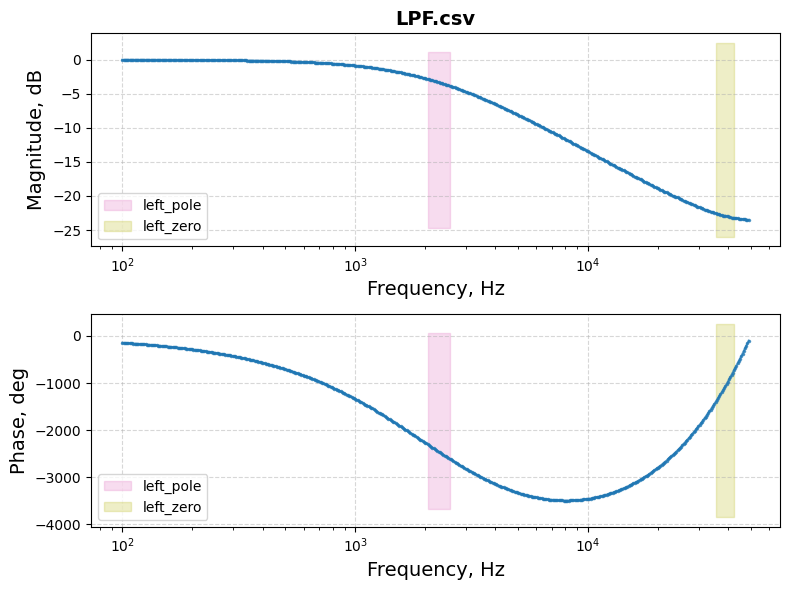

In [14]:
for data, predictions, sample_file_name in zip(data_list, predictions_list, sample_file_name_list):
    plot_responses(
        plot_config=PLOT_CONFIG,
        data=data,
        title=sample_file_name,
        regions=predictions
        )